In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             roc_curve, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# Load & prepare data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
                'ca', 'thal', 'target']

df = pd.read_csv(url, header=None, names=column_names)
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(), inplace=True)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("✅ Data ready!")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

✅ Data ready!
Train: 242 samples | Test: 61 samples


In [3]:
# Train all 3 models
# Define all models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42)
}

# Train every model and store results
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob)
    }
    print(f"✅ {name} trained! Accuracy: {results[name]['accuracy']*100:.1f}%")

✅ Logistic Regression trained! Accuracy: 88.5%
✅ Decision Tree trained! Accuracy: 75.4%
✅ Random Forest trained! Accuracy: 86.9%


In [4]:
# Compare all models in a table
comparison = pd.DataFrame({
    name: {
        'Accuracy':  f"{v['accuracy']*100:.1f}%",
        'Precision': f"{v['precision']*100:.1f}%",
        'Recall':    f"{v['recall']*100:.1f}%",
        'F1 Score':  f"{v['f1']*100:.1f}%",
        'ROC-AUC':   f"{v['roc_auc']*100:.1f}%"
    }
    for name, v in results.items()
}).T

print("=" * 60)
print("         MODEL COMPARISON RESULTS")
print("=" * 60)
print(comparison.to_string())
print("=" * 60)

         MODEL COMPARISON RESULTS
                    Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression    88.5%     87.9%  90.6%    89.2%   92.0%
Decision Tree          75.4%     77.4%  75.0%    76.2%   75.4%
Random Forest          86.9%     90.0%  84.4%    87.1%   93.0%


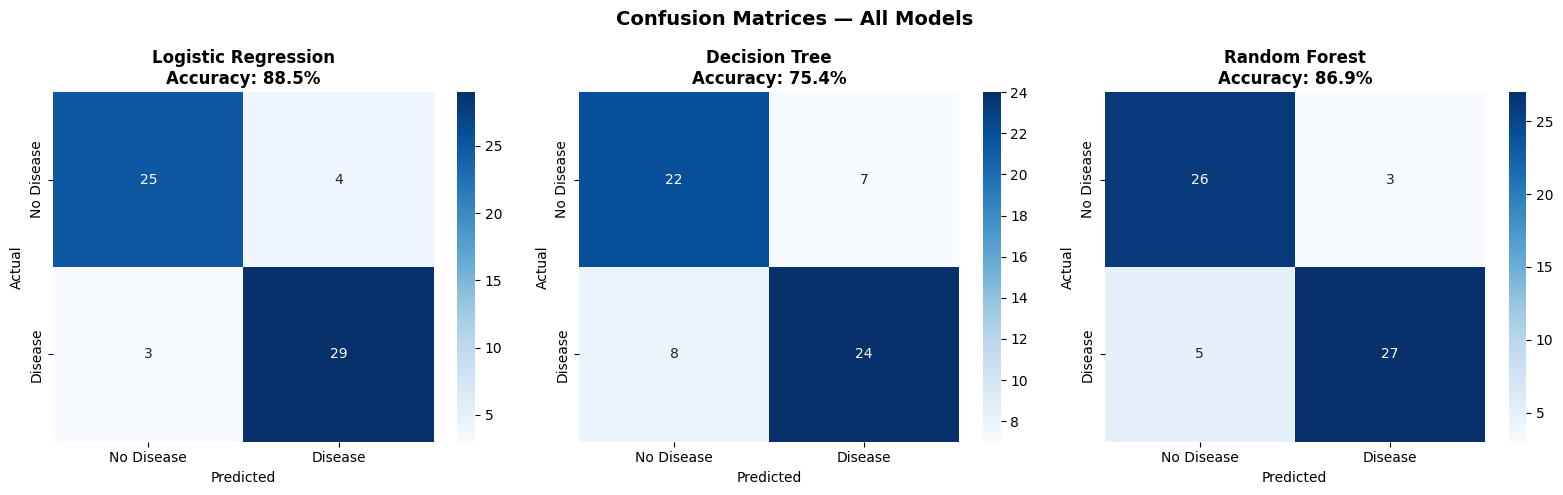

✅ Confusion matrices saved!


In [5]:
 # Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'{name}\nAccuracy: {v["accuracy"]*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot_confusion.png')
plt.show()
print("✅ Confusion matrices saved!")

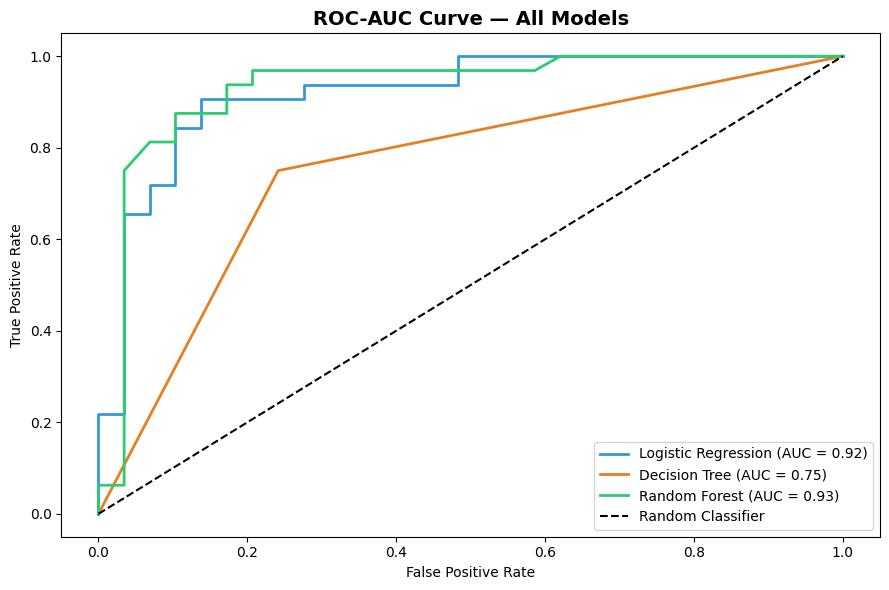

In [6]:
# ROC-AUC curves
plt.figure(figsize=(9, 6))
colors = ['#3498db', '#e67e22', '#2ecc71']

for (name, v), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC = {v['roc_auc']:.2f})")

plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../data/plot_roc.png')
plt.show()

In [7]:
 # Hyperparameter tuning on best model
print("🔍 Tuning Random Forest (this may take ~1 minute)...")

param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [3, 5, 10, None],
    'min_samples_split':[2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Tuned Accuracy : {accuracy_score(y_test, y_pred_best)*100:.1f}%")
print(f"✅ Tuned ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.3f}")

🔍 Tuning Random Forest (this may take ~1 minute)...

✅ Best parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
✅ Tuned Accuracy : 88.5%
✅ Tuned ROC-AUC  : 0.955


In [8]:
# Cross validation check
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='accuracy')

print("Cross-Validation Results (5 folds):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score*100:.1f}%")
print(f"\nMean CV Accuracy: {cv_scores.mean()*100:.1f}%")
print(f"Std Deviation   : {cv_scores.std()*100:.1f}%")

Cross-Validation Results (5 folds):
  Fold 1: 80.3%
  Fold 2: 91.8%
  Fold 3: 82.0%
  Fold 4: 78.3%
  Fold 5: 78.3%

Mean CV Accuracy: 82.2%
Std Deviation   : 5.0%


In [10]:
# Save the final model
import os
os.makedirs('../models', exist_ok=True)

# Save best model and scaler
joblib.dump(best_model, '../models/heart_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')

print("✅ Model saved  → models/heart_model.pkl")
print("✅ Scaler saved → models/scaler.pkl")
print("\n🎉 Step 4 Complete! Models are ready for the Flask API.")

✅ Model saved  → models/heart_model.pkl
✅ Scaler saved → models/scaler.pkl

🎉 Step 4 Complete! Models are ready for the Flask API.
